# TinyBERT Intent Classification — MathDial Dataset
**Model:** `huawei-noah/TinyBERT_General_4L_312D`  
**Task:** 11-class teacher intent classification on the MathDial tutoring dialog corpus  
**Optimized for:** Google Colab T4 GPU  

Two input variants are trained:
- **V1** — prior dialog history + current teacher utterance → predict current intent  
- **V2** — prior dialog history only → predict next teacher intent  


In [1]:
# ============================================================
# 0. Install / upgrade dependencies  (run once, restart runtime)
# ============================================================
!pip install -q --upgrade transformers datasets scikit-learn pandas numpy matplotlib seaborn
# TinyBERT lives in the standard HuggingFace hub — no extra install needed
print('Done installing packages.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 103.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
db-d

In [2]:
# ============================================================
# 0. Fix NumPy/pandas binary incompatibility  ← run FIRST, then restart runtime
# ============================================================
import subprocess, sys

# Uninstall conflicting packages completely
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', 'numpy', 'pandas', 'scipy', 'scikit-learn'], check=False)

# Reinstall pinned compatible versions known to work on Colab T4 (Python 3.12)
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy==1.26.4',
    'pandas==2.2.2',
    'scipy==1.13.1',
    'scikit-learn==1.5.2',
    'matplotlib==3.9.2',
    'seaborn==0.13.2',
    '--force-reinstall',
    '--no-cache-dir',
], check=True)

print('✓ All packages reinstalled with compatible versions.')
print('⚠️  NOW GO TO:  Runtime → Restart session  — then run the rest of the notebook.')

✓ All packages reinstalled with compatible versions.
⚠️  NOW GO TO:  Runtime → Restart session  — then run the rest of the notebook.


In [3]:
# ============================================================
# 1. Download MathDial dataset from GitHub  (auto-discovers correct path)
# ============================================================
import os, requests

REPO     = 'Kpetyxova/autoTree'
BRANCH   = 'main'
# Candidate subfolder paths to try (in order)
CANDIDATES = [
    'mathdial',
    'data_final_mathdial',
    'mathdial/data',
    'data/mathdial',
]
TARGET_FILES = [
    'dialogs_train_annotated.tsv',
    'dialogs_val_annotated.tsv',
    'dialogs_test_annotated.tsv',
]

def list_github_folder(repo, branch, path):
    """Return list of file names in a GitHub folder via the Contents API."""
    url = f'https://api.github.com/repos/{repo}/contents/{path}?ref={branch}'
    r = requests.get(url, headers={'Accept': 'application/vnd.github.v3+json'})
    if r.status_code == 200:
        return r.json()   # list of dicts with 'name', 'download_url', etc.
    return None

def find_and_download(repo, branch, candidates, target_files):
    for folder in candidates:
        contents = list_github_folder(repo, branch, folder)
        if contents is None:
            print(f'  Folder not found: {folder}')
            continue
        names = {item['name']: item['download_url'] for item in contents if item['type'] == 'file'}
        if all(f in names for f in target_files):
            print(f'✓ Found all files in: {folder}')
            for fname in target_files:
                if os.path.exists(fname):
                    print(f'  Already exists: {fname}')
                    continue
                print(f'  Downloading {fname} ...')
                r = requests.get(names[fname])
                r.raise_for_status()
                with open(fname, 'wb') as fout:
                    fout.write(r.content)
                print(f'  Saved {fname}')
            return True
        else:
            found = [f for f in target_files if f in names]
            print(f'  Folder {folder!r} exists but only has: {found}')
    return False

# --- Also try listing all subfolders of mathdial recursively via Trees API ---
def find_via_git_tree(repo, branch, target_files):
    url = f'https://api.github.com/repos/{repo}/git/trees/{branch}?recursive=1'
    r = requests.get(url, headers={'Accept': 'application/vnd.github.v3+json'})
    if r.status_code != 200:
        print('Git tree API failed:', r.status_code)
        return False
    tree = r.json().get('tree', [])
    # Find paths matching our target filenames
    matches = {item['path']: item for item in tree if item['path'].split('/')[-1] in target_files}
    if not matches:
        print('Files not found anywhere in the tree.')
        return False
    # Group by parent folder
    from collections import defaultdict
    by_folder = defaultdict(list)
    for path, item in matches.items():
        folder = '/'.join(path.split('/')[:-1])
        by_folder[folder].append((path.split('/')[-1], path))
    # Pick the folder that has all 3 files
    for folder, items in by_folder.items():
        if len(items) == len(target_files):
            print(f'✓ Found all files in: {folder}')
            for fname, fpath in items:
                if os.path.exists(fname):
                    print(f'  Already exists: {fname}')
                    continue
                raw_url = f'https://raw.githubusercontent.com/{repo}/{branch}/{fpath}'
                print(f'  Downloading from: {raw_url}')
                r2 = requests.get(raw_url)
                r2.raise_for_status()
                with open(fname, 'wb') as fout:
                    fout.write(r2.content)
                print(f'  Saved {fname}')
            return True
    print('Could not find a folder with all 3 files together.')
    return False

# Try candidate folders first, then fall back to full tree scan
success = find_and_download(REPO, BRANCH, CANDIDATES, TARGET_FILES)
if not success:
    print('\nFalling back to full repository tree scan ...')
    success = find_via_git_tree(REPO, BRANCH, TARGET_FILES)

if not success:
    raise RuntimeError(
        'Could not download the dataset automatically. '
        'Please manually upload the 3 TSV files to your Colab session:\n'
        '  dialogs_train_annotated.tsv\n'
        '  dialogs_val_annotated.tsv\n'
        '  dialogs_test_annotated.tsv\n'
        'You can get them from: https://github.com/Kpetyxova/autoTree'
    )

print('\nAll files ready.')

  Folder 'mathdial' exists but only has: []
  Folder not found: data_final_mathdial
  Folder not found: mathdial/data
  Folder not found: data/mathdial

Falling back to full repository tree scan ...
✓ Found all files in: mathdial/annotation
  Already exists: dialogs_test_annotated.tsv
  Already exists: dialogs_train_annotated.tsv
  Already exists: dialogs_val_annotated.tsv

All files ready.


In [4]:
# ============================================================
# 1. Download MathDial dataset from GitHub
# ============================================================
import subprocess, os
import requests # Import requests library

BASE_URL = 'https://raw.githubusercontent.com/Kpetyxova/autoTree/main/data_final_mathdial/'
FILES = [
    'dialogs_train_annotated.tsv',
    'dialogs_val_annotated.tsv',
    'dialogs_test_annotated.tsv',
]

for fname in FILES:
    if not os.path.exists(fname):
        print(f'Downloading {fname} ...')
        url = BASE_URL + fname
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()  # Raise HTTPError for bad responses (4xx or 5xx)
            with open(fname, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f'Successfully downloaded {fname}')
        except requests.exceptions.RequestException as e:
            print(f'Error downloading {fname}: {e}')
            raise # Re-raise the exception to stop execution on failure
    else:
        print(f'Already exists: {fname}')

print('All files ready.')

Already exists: dialogs_train_annotated.tsv
Already exists: dialogs_val_annotated.tsv
Already exists: dialogs_test_annotated.tsv
All files ready.


In [5]:
# ============================================================
# 2. Load data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('dialogs_train_annotated.tsv', sep='\t', on_bad_lines='skip')
val_df   = pd.read_csv('dialogs_val_annotated.tsv',   sep='\t', on_bad_lines='skip')
test_df  = pd.read_csv('dialogs_test_annotated.tsv',  sep='\t', on_bad_lines='skip')

# 11 teacher-intent classes (same ordering as reference table)
intent_order = [
    'Revealing Strategy',
    'Revealing Answer',
    'Guiding Student Focus',
    'Seek Strategy',
    'Asking for Explanation',
    'Seeking Self Correction',
    'Seeking World Knowledge',
    'Greeting/Fairwell',
    'Recall Relevant Information',
    'Perturbing the Question',
    'General inquiry',
]

print(f"{'Split':<8} {'Rows':<8} {'Dialogs':<10} {'Teacher turns':<15}")
print('-' * 45)
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_convs   = df['Conversation_No'].nunique()
    n_teacher = len(df[(df['Speaker'] == 'Teacher') & (df['Predicted_Intents'].isin(intent_order))])
    print(f'{name:<8} {len(df):<8} {n_convs:<10} {n_teacher:<15}')

print(f'\nLabels ({len(intent_order)}): {intent_order}')

Split    Rows     Dialogs    Teacher turns  
---------------------------------------------
Train    8154     500        5174           
Val      160      11         100            
Test     152      10         99             

Labels (11): ['Revealing Strategy', 'Revealing Answer', 'Guiding Student Focus', 'Seek Strategy', 'Asking for Explanation', 'Seeking Self Correction', 'Seeking World Knowledge', 'Greeting/Fairwell', 'Recall Relevant Information', 'Perturbing the Question', 'General inquiry']


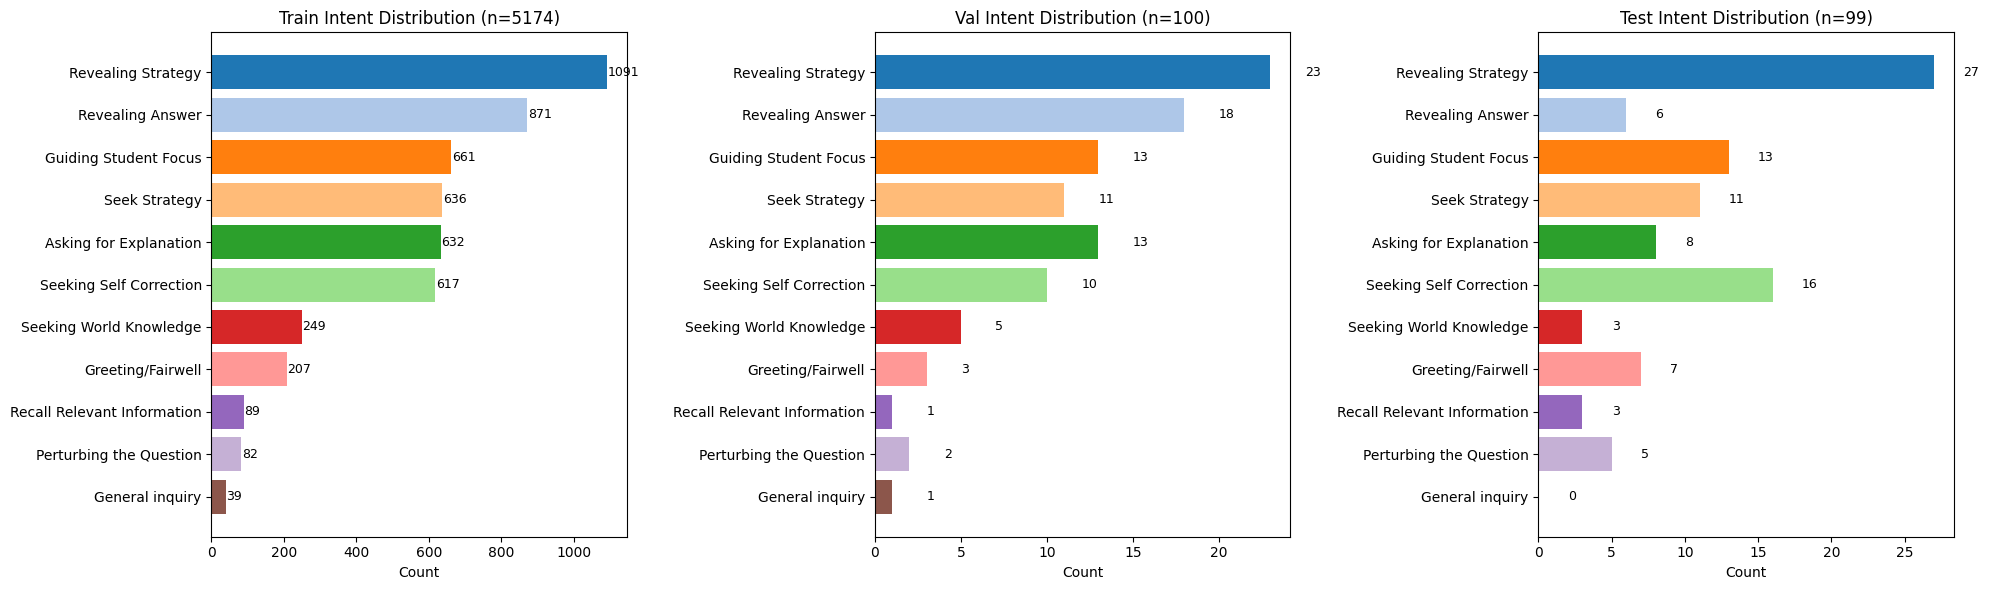

In [6]:
# ============================================================
# 3. Visualise intent distribution
# ============================================================
train_teacher = train_df[train_df['Speaker'] == 'Teacher'].copy()
val_teacher   = val_df[val_df['Speaker'] == 'Teacher'].copy()
test_teacher  = test_df[test_df['Speaker'] == 'Teacher'].copy()
colors = sns.color_palette('tab20', len(intent_order))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, df_t) in zip(axes, [('Train', train_teacher), ('Val', val_teacher), ('Test', test_teacher)]):
    counts = df_t['Predicted_Intents'].value_counts().reindex(intent_order, fill_value=0)
    bars = ax.barh(intent_order, counts, color=colors)
    ax.set_title(f'{name} Intent Distribution (n={len(df_t)})', fontsize=12)
    ax.set_xlabel('Count')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2, str(int(c)), va='center', fontsize=9)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 4. Build dialog samples (V1 & V2)
# ============================================================
def build_dialog_samples(df):
    """
    Each teacher turn = 1 independent sample.
    V1: prior context (tagged) + current teacher utterance.
    V2: prior context (tagged) only.
    """
    v1_samples, v2_samples = [], []
    for conv_no, conv_df in df.groupby('Conversation_No'):
        conv_df = conv_df.sort_values('Utterance_Index')
        turns = conv_df[['Speaker', 'Text', 'Predicted_Intents']].values.tolist()
        for i, (speaker, text, pred_intent) in enumerate(turns):
            if speaker == 'Teacher' and pd.notna(pred_intent) and pred_intent in intent_order:
                prior_parts = []
                for prev_speaker, prev_text, prev_intent in turns[:i]:
                    if prev_speaker == 'Teacher' and pd.notna(prev_intent) and prev_intent in intent_order:
                        prior_parts.append(f'Teacher [{prev_intent}]: {str(prev_text)}')
                    elif prev_speaker == 'Student':
                        prior_parts.append(f'Student: {str(prev_text)}')
                current = f'Teacher: {str(text)}'
                v1_text = ' [SEP] '.join(prior_parts + [current]) if prior_parts else current
                v2_text = ' [SEP] '.join(prior_parts) if prior_parts else '[NO CONTEXT]'
                v1_samples.append({'text': v1_text, 'label': pred_intent, 'conv': conv_no, 'turn': i})
                v2_samples.append({'text': v2_text, 'label': pred_intent, 'conv': conv_no, 'turn': i})
    return pd.DataFrame(v1_samples), pd.DataFrame(v2_samples)


train_v1, train_v2 = build_dialog_samples(train_df)
val_v1,   val_v2   = build_dialog_samples(val_df)
test_v1,  test_v2  = build_dialog_samples(test_df)

print(f"{'Split':<8} {'V1 samples':<15} {'V2 samples':<15}")
print('-' * 38)
for name, v1, v2 in [('Train', train_v1, train_v2), ('Val', val_v1, val_v2), ('Test', test_v1, test_v2)]:
    print(f'{name:<8} {len(v1):<15} {len(v2):<15}')

print(f'\nTrain label distribution:\n{train_v1["label"].value_counts()}')

Split    V1 samples      V2 samples     
--------------------------------------
Train    5174            5174           
Val      100             100            
Test     99              99             

Train label distribution:
label
Revealing Strategy             1091
Revealing Answer                871
Guiding Student Focus           661
Seek Strategy                   636
Asking for Explanation          632
Seeking Self Correction         617
Seeking World Knowledge         249
Greeting/Fairwell               207
Recall Relevant Information      89
Perturbing the Question          82
General inquiry                  39
Name: count, dtype: int64


In [8]:
# ============================================================
# 5. Tokenization & PyTorch Datasets  (TinyBERT)
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# TinyBERT checkpoint (4-layer, 312-dim — fits comfortably on T4)
TINYBERT_CHECKPOINT = 'huawei-noah/TinyBERT_General_4L_312D'

label2id = {label: i for i, label in enumerate(intent_order)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(intent_order)
print(f'Number of classes: {num_labels}')

# TinyBERT uses the same BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(TINYBERT_CHECKPOINT)

# TinyBERT max position embeddings = 512; use 256 for speed on T4
MAX_LEN   = 256
BATCH_SIZE = 32   # TinyBERT is ~4× smaller than BERT-base → larger batch OK


class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor([label2id[l] for l in labels], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }


print('Building datasets ...')
train_ds_v1 = IntentDataset(train_v1['text'].tolist(), train_v1['label'].tolist(), tokenizer, MAX_LEN)
val_ds_v1   = IntentDataset(val_v1['text'].tolist(),   val_v1['label'].tolist(),   tokenizer, MAX_LEN)
test_ds_v1  = IntentDataset(test_v1['text'].tolist(),  test_v1['label'].tolist(),  tokenizer, MAX_LEN)

train_ds_v2 = IntentDataset(train_v2['text'].tolist(), train_v2['label'].tolist(), tokenizer, MAX_LEN)
val_ds_v2   = IntentDataset(val_v2['text'].tolist(),   val_v2['label'].tolist(),   tokenizer, MAX_LEN)
test_ds_v2  = IntentDataset(test_v2['text'].tolist(),  test_v2['label'].tolist(),  tokenizer, MAX_LEN)

train_loader_v1 = DataLoader(train_ds_v1, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_v1   = DataLoader(val_ds_v1,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_v1  = DataLoader(test_ds_v1,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

train_loader_v2 = DataLoader(train_ds_v2, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_v2   = DataLoader(val_ds_v2,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_v2  = DataLoader(test_ds_v2,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'V1 → Train: {len(train_ds_v1)} | Val: {len(val_ds_v1)} | Test: {len(test_ds_v1)}')
print(f'V2 → Train: {len(train_ds_v2)} | Val: {len(val_ds_v2)} | Test: {len(test_ds_v2)}')

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Number of classes: 11


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Building datasets ...
V1 → Train: 5174 | Val: 100 | Test: 99
V2 → Train: 5174 | Val: 100 | Test: 99


In [9]:
# ============================================================
# 6. Evaluation helper
# ============================================================
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels

In [10]:
# ============================================================
# 7. Training function  (TinyBERT — T4-optimised)
# ============================================================
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

def train_model(train_loader, val_loader, save_name, epochs=20, lr=3e-5):
    """
    Fine-tune TinyBERT for sequence classification.
    Hyperparameters tuned for T4 (15 GB VRAM), batch_size=32, max_len=256.
    lr=3e-5 works well for TinyBERT (slightly higher than BERT-base 2e-5).
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        TINYBERT_CHECKPOINT,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,   # classifier head is newly initialised
    ).to(device)

    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    history     = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0.0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_train_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_train_loss / len(train_loader)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), save_name)

        print(f'  Epoch {epoch+1:>2}/{epochs} | Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}'
              + (' ← best' if val_f1 == best_val_f1 else ''))

    print(f'\n  Best Val F1: {best_val_f1:.4f}\n')
    return model, history


print('Training function defined. TinyBERT checkpoint:', TINYBERT_CHECKPOINT)

Training function defined. TinyBERT checkpoint: huawei-noah/TinyBERT_General_4L_312D


In [11]:
# ============================================================
# 8. Train V1 — history + current utterance
# ============================================================
print('=' * 65)
print('TinyBERT  V1: prior dialog history + current teacher utterance')
print('=' * 65)
model_v1, history_v1 = train_model(train_loader_v1, val_loader_v1, 'best_tinybert_v1.pt', epochs=20)

TinyBERT  V1: prior dialog history + current teacher utterance


pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

  Epoch  1/20 | Train Loss: 2.3311 | Val Loss: 2.2210 | Val Acc: 0.2900 | Val F1: 0.1687 ← best
  Epoch  2/20 | Train Loss: 2.0838 | Val Loss: 2.0880 | Val Acc: 0.3300 | Val F1: 0.1780 ← best
  Epoch  3/20 | Train Loss: 1.9586 | Val Loss: 2.0039 | Val Acc: 0.3300 | Val F1: 0.1780 ← best
  Epoch  4/20 | Train Loss: 1.8995 | Val Loss: 1.9913 | Val Acc: 0.3600 | Val F1: 0.2481 ← best
  Epoch  5/20 | Train Loss: 1.8583 | Val Loss: 2.0092 | Val Acc: 0.3600 | Val F1: 0.2508 ← best
  Epoch  6/20 | Train Loss: 1.8216 | Val Loss: 1.9859 | Val Acc: 0.3500 | Val F1: 0.2375
  Epoch  7/20 | Train Loss: 1.7927 | Val Loss: 1.9850 | Val Acc: 0.3300 | Val F1: 0.2395
  Epoch  8/20 | Train Loss: 1.7648 | Val Loss: 1.9835 | Val Acc: 0.3500 | Val F1: 0.2512 ← best
  Epoch  9/20 | Train Loss: 1.7468 | Val Loss: 1.9578 | Val Acc: 0.3600 | Val F1: 0.2645 ← best
  Epoch 10/20 | Train Loss: 1.7152 | Val Loss: 1.9875 | Val Acc: 0.3500 | Val F1: 0.2529
  Epoch 11/20 | Train Loss: 1.7020 | Val Loss: 2.0027 | Val A

In [12]:
# ============================================================
# 9. Train V2 — history only
# ============================================================
print('=' * 65)
print('TinyBERT  V2: prior dialog history only (no current utterance)')
print('=' * 65)
model_v2, history_v2 = train_model(train_loader_v2, val_loader_v2, 'best_tinybert_v2.pt', epochs=20)

TinyBERT  V2: prior dialog history only (no current utterance)


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

  Epoch  1/20 | Train Loss: 2.3268 | Val Loss: 2.2247 | Val Acc: 0.2800 | Val F1: 0.1621 ← best
  Epoch  2/20 | Train Loss: 2.0941 | Val Loss: 2.1177 | Val Acc: 0.2900 | Val F1: 0.1657 ← best
  Epoch  3/20 | Train Loss: 2.0043 | Val Loss: 2.1178 | Val Acc: 0.2900 | Val F1: 0.1678 ← best
  Epoch  4/20 | Train Loss: 1.9775 | Val Loss: 2.1382 | Val Acc: 0.3100 | Val F1: 0.2312 ← best
  Epoch  5/20 | Train Loss: 1.9596 | Val Loss: 2.1428 | Val Acc: 0.3100 | Val F1: 0.2272
  Epoch  6/20 | Train Loss: 1.9415 | Val Loss: 2.1008 | Val Acc: 0.3000 | Val F1: 0.2153
  Epoch  7/20 | Train Loss: 1.9248 | Val Loss: 2.1623 | Val Acc: 0.2800 | Val F1: 0.1925
  Epoch  8/20 | Train Loss: 1.9136 | Val Loss: 2.0840 | Val Acc: 0.3200 | Val F1: 0.2311
  Epoch  9/20 | Train Loss: 1.8944 | Val Loss: 2.1003 | Val Acc: 0.2900 | Val F1: 0.2177
  Epoch 10/20 | Train Loss: 1.8758 | Val Loss: 2.1162 | Val Acc: 0.3100 | Val F1: 0.2381 ← best
  Epoch 11/20 | Train Loss: 1.8655 | Val Loss: 2.1556 | Val Acc: 0.3100 | V

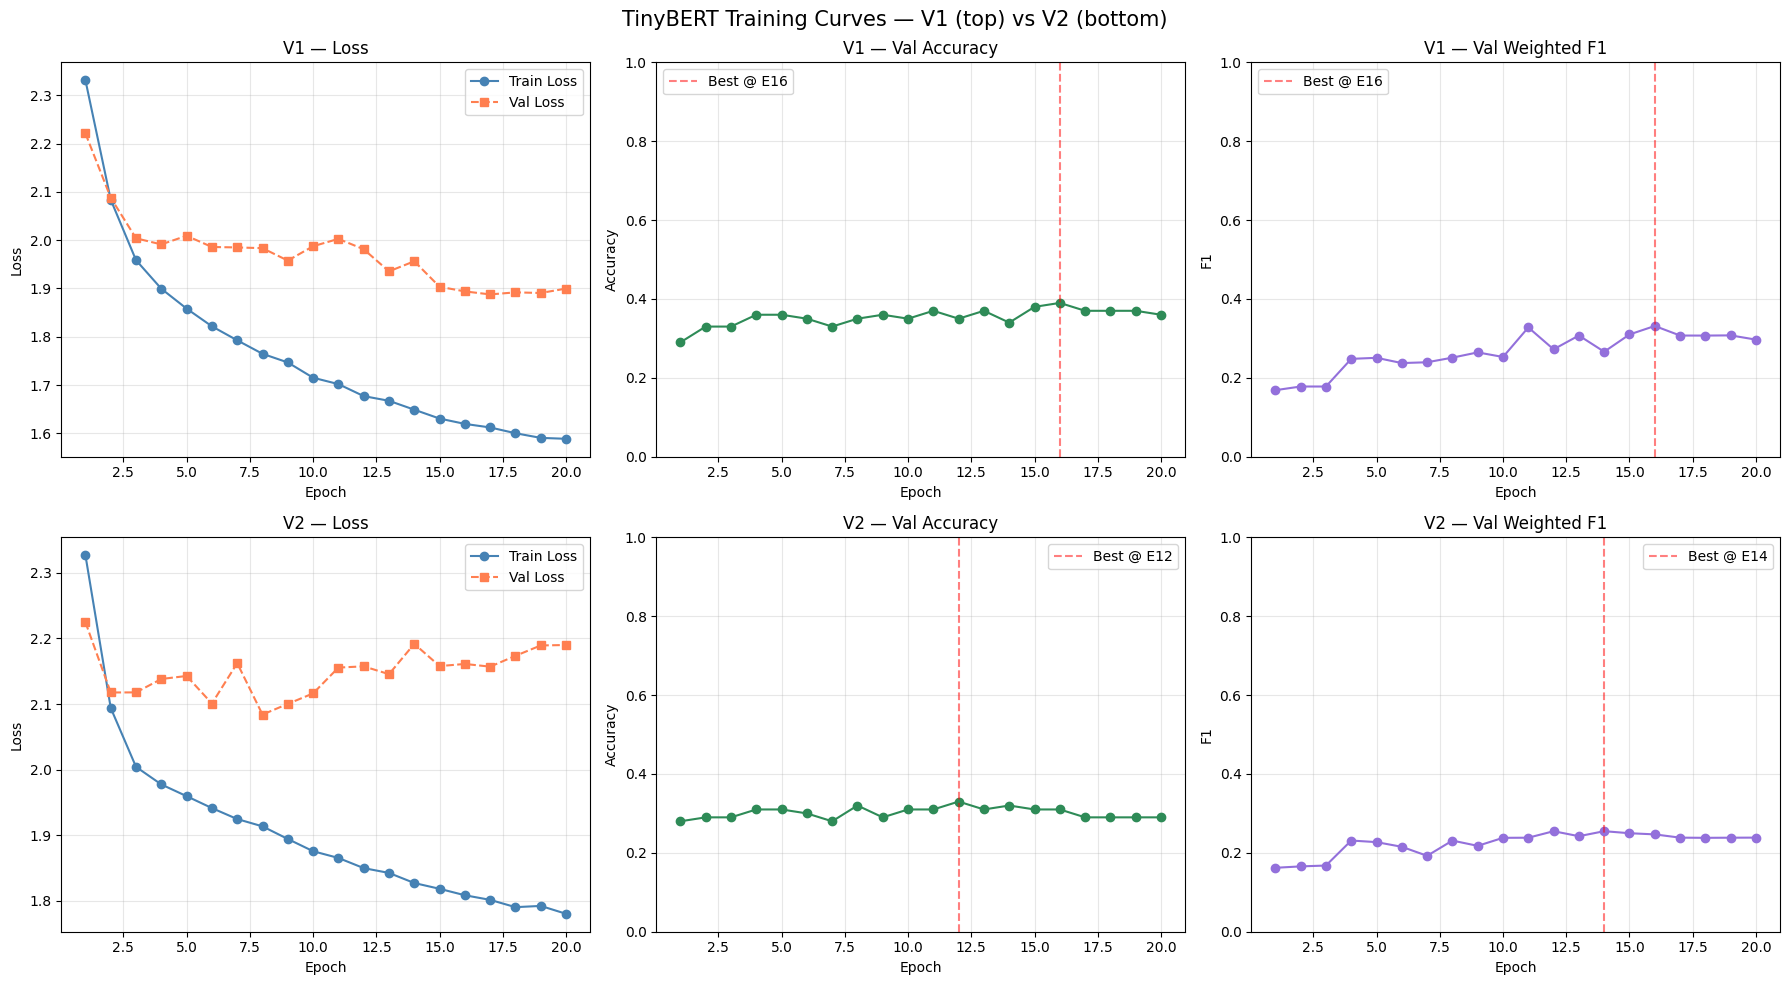

V1 — Best Val F1: 0.3315  (Epoch 16)
V2 — Best Val F1: 0.2549  (Epoch 14)


In [13]:
# ============================================================
# 10. Training curves
# ============================================================
epochs_range = range(1, 21)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('TinyBERT Training Curves — V1 (top) vs V2 (bottom)', fontsize=15)

for row, (history, label) in enumerate([(history_v1, 'V1'), (history_v2, 'V2')]):
    axes[row, 0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='steelblue')
    axes[row, 0].plot(epochs_range, history['val_loss'],   's--', label='Val Loss',  color='coral')
    axes[row, 0].set_title(f'{label} — Loss'); axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(epochs_range, history['val_acc'], 'o-', color='seagreen')
    axes[row, 1].set_title(f'{label} — Val Accuracy'); axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].set_ylim(0, 1); axes[row, 1].grid(alpha=0.3)
    best_ep = history['val_acc'].index(max(history['val_acc'])) + 1
    axes[row, 1].axvline(best_ep, color='red', linestyle='--', alpha=0.5, label=f'Best @ E{best_ep}')
    axes[row, 1].legend()

    axes[row, 2].plot(epochs_range, history['val_f1'], 'o-', color='mediumpurple')
    axes[row, 2].set_title(f'{label} — Val Weighted F1'); axes[row, 2].set_xlabel('Epoch'); axes[row, 2].set_ylabel('F1')
    axes[row, 2].set_ylim(0, 1); axes[row, 2].grid(alpha=0.3)
    best_ep = history['val_f1'].index(max(history['val_f1'])) + 1
    axes[row, 2].axvline(best_ep, color='red', linestyle='--', alpha=0.5, label=f'Best @ E{best_ep}')
    axes[row, 2].legend()

plt.tight_layout()
plt.show()
print(f'V1 — Best Val F1: {max(history_v1["val_f1"]):.4f}  (Epoch {history_v1["val_f1"].index(max(history_v1["val_f1"]))+1})')
print(f'V2 — Best Val F1: {max(history_v2["val_f1"]):.4f}  (Epoch {history_v2["val_f1"].index(max(history_v2["val_f1"]))+1})')

In [16]:
# ============================================================
# 11. Test evaluation — V1
# ============================================================
model_v1.load_state_dict(torch.load('best_tinybert_v1.pt', map_location=device))
_, test_acc_v1, test_f1_v1, preds_v1, labels_v1 = evaluate(model_v1, test_loader_v1)

print('=' * 65)
print(f'TinyBERT V1 Test  |  Acc: {test_acc_v1:.4f}  |  Weighted F1: {test_f1_v1:.4f}')
print('=' * 65)
print(classification_report(
    labels_v1, preds_v1,
    target_names=intent_order,
    labels=list(range(num_labels)), # Explicitly specify all possible labels
    digits=4,
    zero_division=0
))

TinyBERT V1 Test  |  Acc: 0.3838  |  Weighted F1: 0.3177
                             precision    recall  f1-score   support

         Revealing Strategy     0.4286    0.7778    0.5526        27
           Revealing Answer     0.2500    0.3333    0.2857         6
      Guiding Student Focus     0.3333    0.4615    0.3871        13
              Seek Strategy     0.1250    0.0909    0.1053        11
     Asking for Explanation     0.5714    0.5000    0.5333         8
    Seeking Self Correction     0.0000    0.0000    0.0000        16
    Seeking World Knowledge     0.2500    0.3333    0.2857         3
          Greeting/Fairwell     0.6000    0.4286    0.5000         7
Recall Relevant Information     0.0000    0.0000    0.0000         3
    Perturbing the Question     0.0000    0.0000    0.0000         5
            General inquiry     0.0000    0.0000    0.0000         0

                   accuracy                         0.3838        99
                  macro avg     0.2326    0.

In [17]:
# ============================================================
# 12. Test evaluation — V2
# ============================================================
model_v2.load_state_dict(torch.load('best_tinybert_v2.pt', map_location=device))
_, test_acc_v2, test_f1_v2, preds_v2, labels_v2 = evaluate(model_v2, test_loader_v2)

print('=' * 65)
print(f'TinyBERT V2 Test  |  Acc: {test_acc_v2:.4f}  |  Weighted F1: {test_f1_v2:.4f}')
print('=' * 65)
print(classification_report(
    labels_v2, preds_v2,
    target_names=intent_order,
    labels=list(range(num_labels)), # Explicitly specify all possible labels
    digits=4,
    zero_division=0
))

TinyBERT V2 Test  |  Acc: 0.2727  |  Weighted F1: 0.1845
                             precision    recall  f1-score   support

         Revealing Strategy     0.3226    0.7407    0.4494        27
           Revealing Answer     0.1667    0.5000    0.2500         6
      Guiding Student Focus     0.2000    0.0769    0.1111        13
              Seek Strategy     0.0000    0.0000    0.0000        11
     Asking for Explanation     0.1818    0.2500    0.2105         8
    Seeking Self Correction     0.0000    0.0000    0.0000        16
    Seeking World Knowledge     1.0000    0.3333    0.5000         3
          Greeting/Fairwell     0.0000    0.0000    0.0000         7
Recall Relevant Information     0.0000    0.0000    0.0000         3
    Perturbing the Question     0.0000    0.0000    0.0000         5
            General inquiry     0.0000    0.0000    0.0000         0

                   accuracy                         0.2727        99
                  macro avg     0.1701    0.

In [20]:
# ============================================================
# 13. Pretty classification-report table  (replicates the
#     reference image format with 4-decimal precision)
# ============================================================
from sklearn.metrics import precision_recall_fscore_support

def print_report_table(labels_true, labels_pred, model_name='TinyBERT'):
    """
    Prints a formatted table matching the reference image:
    columns: precision | recall | f1-score | support
    rows: per class + accuracy + macro avg + weighted avg
    """
    label_ids = list(range(num_labels))
    prec, rec, f1, sup = precision_recall_fscore_support(
        labels_true, labels_pred,
        labels=label_ids,
        zero_division=0
    )
    acc   = accuracy_score(labels_true, labels_pred)
    total = len(labels_true)

    mac_p,  mac_r,  mac_f,  _ = precision_recall_fscore_support(labels_true, labels_pred, average='macro',    zero_division=0)
    wgt_p,  wgt_r,  wgt_f,  _ = precision_recall_fscore_support(labels_true, labels_pred, average='weighted', zero_division=0)

    col_w = 30  # width of the class-name column
    header = f"{':':>{col_w}}  {'precision':>10}  {'recall':>10}  {'f1-score':>10}  {'support':>10}"
    sep    = '-' * len(header)

    print(f'\n{model_name} Classification Report')
    print(sep)
    print(header)
    print(sep)

    for i, intent in enumerate(intent_order):
        print(f"{intent:>{col_w}}  {prec[i]:>10.4f}  {rec[i]:>10.4f}  {f1[i]:>10.4f}  {int(sup[i]):>10}")

    print(sep)
    print(f"{'accuracy':>{col_w}}  {'':>10}  {'':>10}  {acc:>10.4f}  {total:>10}")
    print(f"{'macro avg':>{col_w}}  {mac_p:>10.4f}  {mac_r:>10.4f}  {mac_f:>10.4f}  {total:>10}")
    print(f"{'weighted avg':>{col_w}}  {wgt_p:>10.4f}  {wgt_r:>10.4f}  {wgt_f:>10.4f}  {total:>10}")
    print(sep)


print_report_table(labels_v1, preds_v1, model_name='TinyBERT V1 (history + current utterance)')
print_report_table(labels_v2, preds_v2, model_name='TinyBERT V2 (history only)')


TinyBERT V1 (history + current utterance) Classification Report
------------------------------------------------------------------------------
                             :   precision      recall    f1-score     support
------------------------------------------------------------------------------
            Revealing Strategy      0.4286      0.7778      0.5526          27
              Revealing Answer      0.2500      0.3333      0.2857           6
         Guiding Student Focus      0.3333      0.4615      0.3871          13
                 Seek Strategy      0.1250      0.0909      0.1053          11
        Asking for Explanation      0.5714      0.5000      0.5333           8
       Seeking Self Correction      0.0000      0.0000      0.0000          16
       Seeking World Knowledge      0.2500      0.3333      0.2857           3
             Greeting/Fairwell      0.6000      0.4286      0.5000           7
   Recall Relevant Information      0.0000      0.0000      0.0000

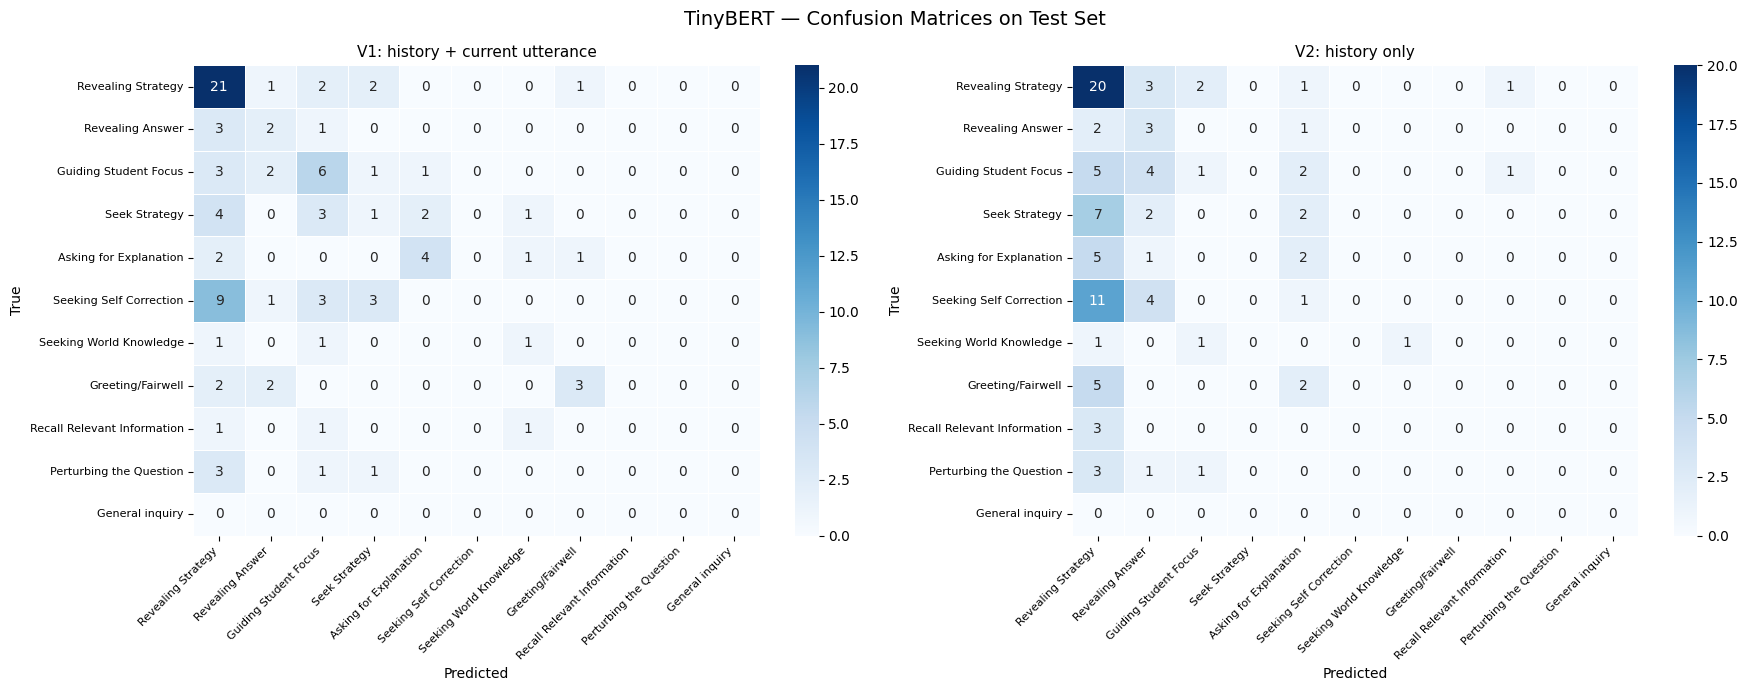

In [21]:
# ============================================================
# 14. Confusion matrices
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('TinyBERT — Confusion Matrices on Test Set', fontsize=14)

for ax, preds, true_labels, title in [
    (axes[0], preds_v1, labels_v1, 'V1: history + current utterance'),
    (axes[1], preds_v2, labels_v2, 'V2: history only'),
]:
    cm = confusion_matrix(true_labels, preds, labels=list(range(num_labels)))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=intent_order, yticklabels=intent_order,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 15. Summary comparison table  (V1 vs V2)
# ============================================================
from sklearn.metrics import f1_score as sk_f1

print('=' * 70)
print(f"{'TinyBERT SUMMARY':^70}")
print('=' * 70)
print(f"\n{'Metric':<40} {'V1':>13} {'V2':>13}")
print('-' * 70)

best_ep_v1 = history_v1['val_f1'].index(max(history_v1['val_f1'])) + 1
best_ep_v2 = history_v2['val_f1'].index(max(history_v2['val_f1'])) + 1
print(f"{'Best Val F1 (during training)':<40} {max(history_v1['val_f1']):>13.4f} {max(history_v2['val_f1']):>13.4f}")
print(f"{'Best Epoch':<40} {best_ep_v1:>13} {best_ep_v2:>13}")
print(f"{'Final Train Loss':<40} {history_v1['train_loss'][-1]:>13.4f} {history_v2['train_loss'][-1]:>13.4f}")
print('-' * 70)
print(f"{'Test Accuracy':<40} {test_acc_v1:>13.4f} {test_acc_v2:>13.4f}")
print(f"{'Test Weighted F1':<40} {test_f1_v1:>13.4f} {test_f1_v2:>13.4f}")
print('-' * 70)

for intent in intent_order:
    idx = label2id[intent]
    f1_v1 = sk_f1([1 if l == idx else 0 for l in labels_v1],
                   [1 if p == idx else 0 for p in preds_v1], zero_division=0)
    f1_v2 = sk_f1([1 if l == idx else 0 for l in labels_v2],
                   [1 if p == idx else 0 for p in preds_v2], zero_division=0)
    short = intent[:35]
    print(f"  F1 [{short}]{'':<{35-len(short)}} {f1_v1:>13.4f} {f1_v2:>13.4f}")

print('=' * 70)
print('\nV1 = sees current utterance + history → classifies current intent')
print('V2 = history only → predicts next teacher intent without seeing it')
print(f'\nTrain: {len(train_v1)} samples | Val: {len(val_v1)} samples | Test: {len(test_v1)} samples')
print(f'Model: {TINYBERT_CHECKPOINT} (4-layer, 312-dim)')

                           TinyBERT SUMMARY                           

Metric                                              V1            V2
----------------------------------------------------------------------
Best Val F1 (during training)                   0.3315        0.2549
Best Epoch                                          16            14
Final Train Loss                                1.5888        1.7804
----------------------------------------------------------------------
Test Accuracy                                   0.3838        0.2727
Test Weighted F1                                0.3177        0.1845
----------------------------------------------------------------------
  F1 [Revealing Strategy]                         0.5526        0.4494
  F1 [Revealing Answer]                           0.2857        0.2500
  F1 [Guiding Student Focus]                      0.3871        0.1111
  F1 [Seek Strategy]                              0.1053        0.0000
  F1 [Asking for 

In [23]:
# ============================================================
# 16. Save models, predictions & training histories
# ============================================================
import os, json

os.makedirs('saved_tinybert_v1', exist_ok=True)
os.makedirs('saved_tinybert_v2', exist_ok=True)

# HuggingFace format
model_v1.load_state_dict(torch.load('best_tinybert_v1.pt', map_location=device))
model_v1.save_pretrained('saved_tinybert_v1/model')
tokenizer.save_pretrained('saved_tinybert_v1/tokenizer')

model_v2.load_state_dict(torch.load('best_tinybert_v2.pt', map_location=device))
model_v2.save_pretrained('saved_tinybert_v2/model')
tokenizer.save_pretrained('saved_tinybert_v2/tokenizer')

print('Models saved to saved_tinybert_v1/ and saved_tinybert_v2/')

# Predictions CSV
def make_pred_df(v_df, preds, labels, version):
    df_out = v_df[['conv', 'turn', 'label']].copy().reset_index(drop=True)
    df_out['true_label'] = [id2label[l] for l in labels]
    df_out['pred_label'] = [id2label[p] for p in preds]
    df_out['correct']    = df_out['true_label'] == df_out['pred_label']
    df_out['version']    = version
    return df_out

make_pred_df(test_v1, preds_v1, labels_v1, 'TinyBERT-V1').to_csv('predictions_tinybert_v1.csv', index=False)
make_pred_df(test_v2, preds_v2, labels_v2, 'TinyBERT-V2').to_csv('predictions_tinybert_v2.csv', index=False)
print('Predictions saved.')

with open('history_tinybert_v1.json', 'w') as f:
    json.dump(history_v1, f, indent=2)
with open('history_tinybert_v2.json', 'w') as f:
    json.dump(history_v2, f, indent=2)
print('Training histories saved.')
print('\nAll outputs saved successfully.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models saved to saved_tinybert_v1/ and saved_tinybert_v2/
Predictions saved.
Training histories saved.

All outputs saved successfully.
